In [1]:
# load the dataset
import pandas as pd 
bk = pd.read_csv(r"C:\Users\Kanti\Downloads\bikes.csv")
bk.head(10)

,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500
5,KTM Duke 200cc 2012,2012,24561 Km,third owner,bangalore,\n\n 35 kmpl,25 bhp,63400
6,Bajaj Pulsar 180cc 2016,2016,19718 Km,first owner,bangalore,\n\n 65 kmpl,17 bhp,55000
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,Mileage 40 Kmpl,first owner,hyderabad,\n\n 40 Kmpl,20.21 bhp,120000
8,KTM Duke 390cc 2018,2018,1350 Km,first owner,jaipur,\n\n 25 kmpl,42.90 bhp,198000
9,Yamaha FZ16 150cc 2014,2014,Mileage 58 Kmpl,first owner,bangalore,\n\n 58 Kmpl,13 bhp,40000


In [2]:
# check structure
bk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_name  7857 non-null   object
 1   model_year  7857 non-null   int64 
 2   kms_driven  7857 non-null   object
 3   owner       7857 non-null   object
 4   location    7838 non-null   object
 5   mileage     7846 non-null   object
 6   power       7826 non-null   object
 7   price       7857 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 491.2+ KB


In [3]:
# check null values 
bk.isnull().sum()

model_name     0
model_year     0
kms_driven     0
owner          0
location      19
mileage       11
power         31
price          0
dtype: int64

In [4]:
# check duplicate values
duplicate = bk.duplicated().sum()
print("duplicate found : ",duplicate)

duplicate found :  0


In [5]:
# clean individual columns
# brand and engine in model_name column

bk["brand"] = bk["model_name"].str.split().str[0]
bk["engine"] = bk["model_name"].str.extract(r"(\d{2,3})").astype(int) # 2 or 3 digit 

In [6]:
# price column cleaning 
bk["price"] = (
    bk["price"].replace("₹","", regex = False)
    .replace(",","",regex = False)
)

In [7]:
#kms driven column cleaing 
bk["kms_driven"] = pd.to_numeric(
    bk["kms_driven"].str.replace(r"[^0-9]", "", regex = True), errors = "coerce").fillna(0).astype(int)

In [8]:
# Normalize text
# map the owner words and fill null values
owner_map = {
    "first owner":1, "1st owner":1,
    "second owner":2, "2nd owner":2,
    "third owner":3, "3rd owner":3,
    "fourth owner":4, "4th owner":4
}
bk["owner"] = bk["owner"].astype(str).str.lower().map(owner_map).fillna(1)

In [9]:
# power column cleaning and fill null valueas 
bk["power"] = (
    bk["power"]
    .astype(str)
    .str.lower()
    .str.replace("bhp","", regex = False)
    .str.replace(" ","", regex = False)
)
bk["power"] = pd.to_numeric(bk["power"], errors = "coerce") # change datatype
bk["power"] = bk["power"].fillna(bk["power"].median()) # fill null values

In [10]:
# mileage column cleaning and filling 
bk["mileage"] = (
    bk["mileage"]
    .astype(str)
    .str.lower()
    .str.replace("kmpl","", regex = False)
    .str.replace("km/l","", regex = False)
    .str.replace(" ","", regex = False)
)

bk["mileage"] = pd.to_numeric(bk["mileage"], errors = "coerce") # change datatype
bk["mileage"] = bk["mileage"].fillna(bk["mileage"].median()) # fill null values

In [11]:
# location column 
bk["location"] = (
    bk["location"]
    .astype(str)
    .str.strip()
    .str.title()
)
bk["location"] = bk["location"].fillna(bk["location"].mode()[0]) # fill null values

In [12]:
# after data cleaning 
final_bk  = bk[
    ["brand", "engine", "model_year", "kms_driven",
     "owner", "mileage", "power", "location", "price"]
]

In [13]:
final_bk.head(10)

,brand,engine,model_year,kms_driven,owner,mileage,power,location,price
0,Bajaj,220,2017,17000,1.0,35.0,19.00,Hyderabad,63500
1,Royal,350,2016,50000,1.0,35.0,19.80,Hyderabad,115000
2,Hyosung,250,2012,14795,1.0,30.0,28.00,Hyderabad,300000
3,Bajaj,400,2017,28,1.0,40.0,34.50,Pondicherry,100000
4,Jawa,330,2020,2000,1.0,40.0,30.00,Bangalore,197500
5,KTM,200,2012,24561,3.0,35.0,25.00,Bangalore,63400
6,Bajaj,180,2016,19718,1.0,65.0,17.00,Bangalore,55000
7,TVS,200,2020,40,1.0,40.0,20.21,Hyderabad,120000
8,KTM,390,2018,1350,1.0,25.0,42.90,Jaipur,198000
9,Yamaha,16,2014,58,1.0,58.0,13.00,Bangalore,40000


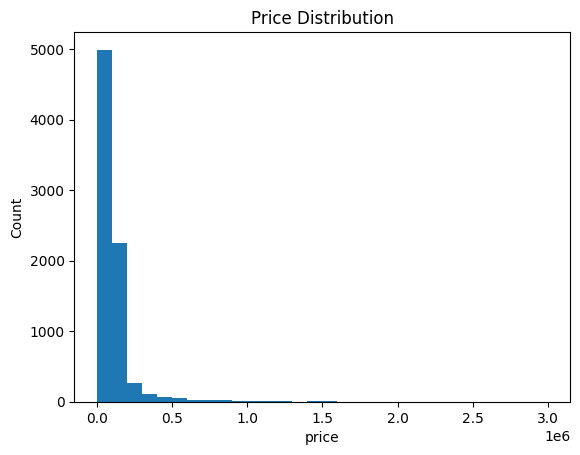

In [14]:
# Explortory Data analysis 
import matplotlib.pyplot as plt # load important librarie 
plt.hist(bk["price"], bins = 30)
plt.xlabel("price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

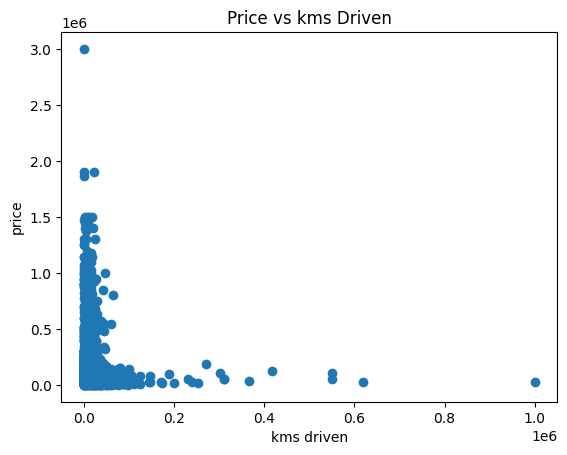

In [15]:
# kms_driven vs price scatter chart
x  = bk["kms_driven"]
y = bk["price"]
plt.scatter(x, y)
plt.xlabel("kms driven")
plt.ylabel("price")
plt.title("Price vs kms Driven")
plt.show()

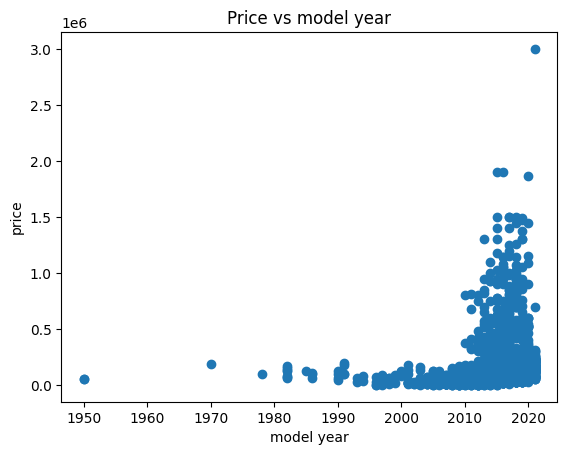

In [16]:
# model_year vs prive scatter chart 
x  = bk["model_year"]
y = bk["price"]
plt.scatter(x, y)
plt.xlabel("model year")
plt.ylabel("price")
plt.title("Price vs model year")
plt.show()

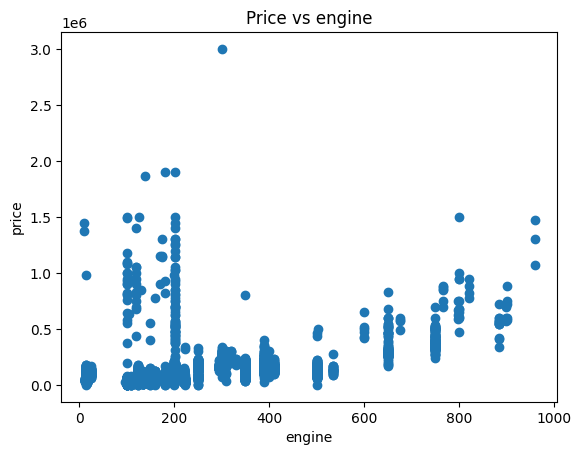

In [17]:
# engine vs prive scatter chart 
x  = bk["engine"]
y = bk["price"]
plt.scatter(x, y)
plt.xlabel("engine")
plt.ylabel("price")
plt.title("Price vs engine")
plt.show()

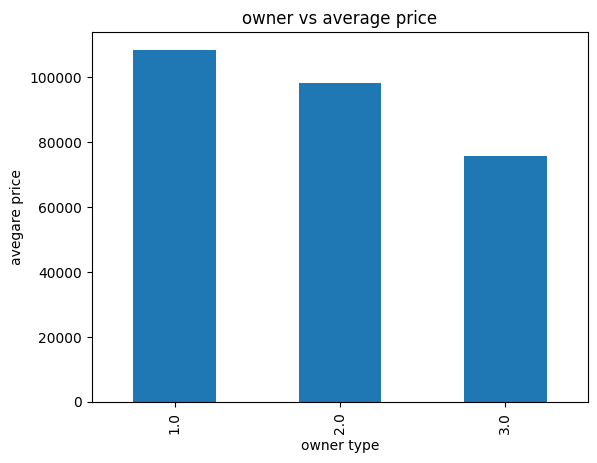

In [18]:
# group owner and price column 
bk.groupby("owner")["price"].mean().plot(kind = "bar")
plt.xlabel("owner type")
plt.ylabel("avegare price")
plt.title("owner vs average price")
plt.show()

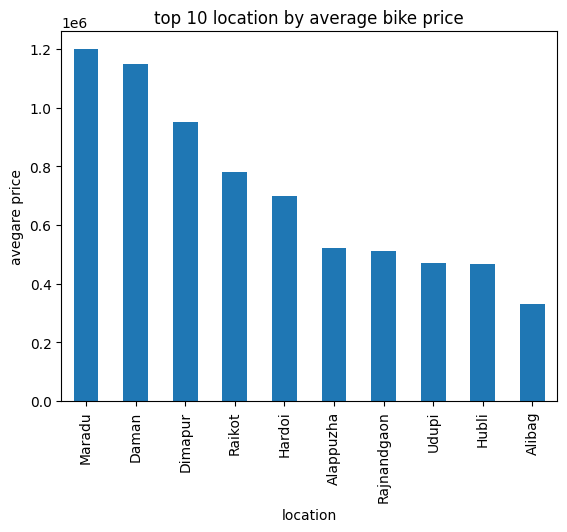

In [19]:
# group location and price column 
top_location = bk.groupby("location")["price"].mean().sort_values(ascending = False).head(10)
top_location.plot(kind = "bar")
plt.xlabel("location")
plt.ylabel("avegare price")
plt.title("top 10 location by average bike price")
plt.show()

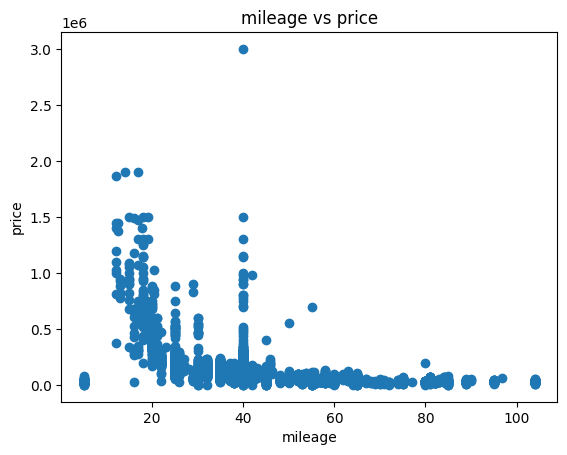

In [20]:
# mileage vs prive scatter chart 
x  = bk["mileage"]
y = bk["price"]
plt.scatter(x, y)
plt.xlabel("mileage")
plt.ylabel("price")
plt.title("mileage vs price")
plt.show()

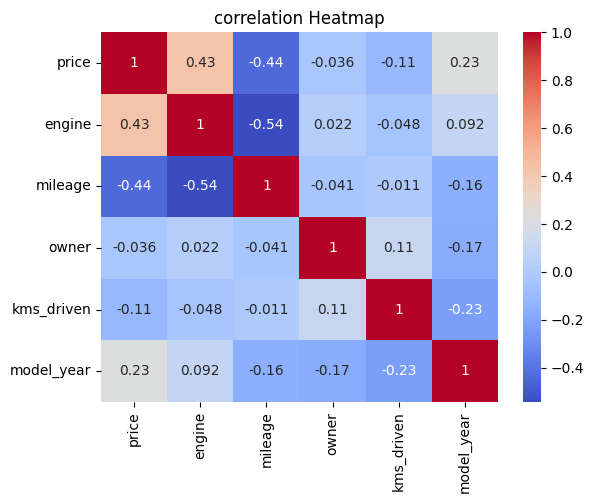

In [21]:
# Correlation by Heatmap
import seaborn as sns       # load important librarie

corr = bk[
    ["price", "engine", "mileage", 
    "owner", "kms_driven", "model_year"]
].corr()
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("correlation Heatmap")
plt.show()

In [22]:
# model building 
# selected required columns
model_bk = bk[
    ["model_year", "price", "kms_driven",
    "engine", "owner", "power", "location"]
]

In [23]:
# Encode Categorical Feature
# use One-hot encoding
model_bk = pd.get_dummies(model_bk, columns = ["location"], drop_first = True)

In [25]:
# split data train and test
from sklearn.model_selection import train_test_split

X = model_bk.drop("price", axis = 1) 
Y = model_bk["price"]

X_train, X_test, Y_train, Y_test, = train_test_split(X,Y, test_size = 0.2, random_state = 40)

In [26]:
# build simple model linear regression
from sklearn.linear_model import LinearRegression
lg = LinearRegression()
lg.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
# model evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np 

y_pred = lg.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
r2 = r2_score(Y_test, y_pred)
print("rmse : ",rmse)
print("r2 : ",r2)

rmse :  68194.61082500544
r2 :  0.6762419555908585


In [27]:
# Feature importance 
#power, engine_cc, model_year → increase price
#kms_driven, owner → decrease price

importance = pd.Series(
    lg.coef_, index = X.columns
).sort_values(ascending =False)
print("importance :", importance)

importance : location_Daman                   721588.111262
location_Raikot                  694859.438028
location_Khalilabad              227835.268431
location_Assandh                 220990.659368
location_Kukatpally              167947.247362
                                     ...      
location_Gangtok                -102293.767189
location_Jajpur                 -121818.463555
location_Challakere             -124132.360772
location_Dadra & Nagar Haveli   -224997.148967
location_Anekal                 -298345.376728
Length: 566, dtype: float64


In [29]:
# build advanced model 
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators = 200,
    random_state = 45
)
rf.fit(X_train, Y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
#Evluation Randon forest model
rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_pred))
rf_r2 = r2_score(Y_test, rf_pred)
print("rf_rmse:",rf_rmse)
print("rf_r2:",rf_r2)

rf_rmse: 51730.37535140068
rf_r2: 0.8137004882017855


In [30]:
# Example bike
sample = X_test.iloc[0:1]

predicted_price = rf.predict(sample)
predicted_price

array([154014.73684211])